In [2]:
import tensorflow as tf
from tensorflow import keras

# MNIST is built directly into Keras - no downloading or file-hunting needed
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

print("\nFirst label:", y_train[0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)

First label: 5


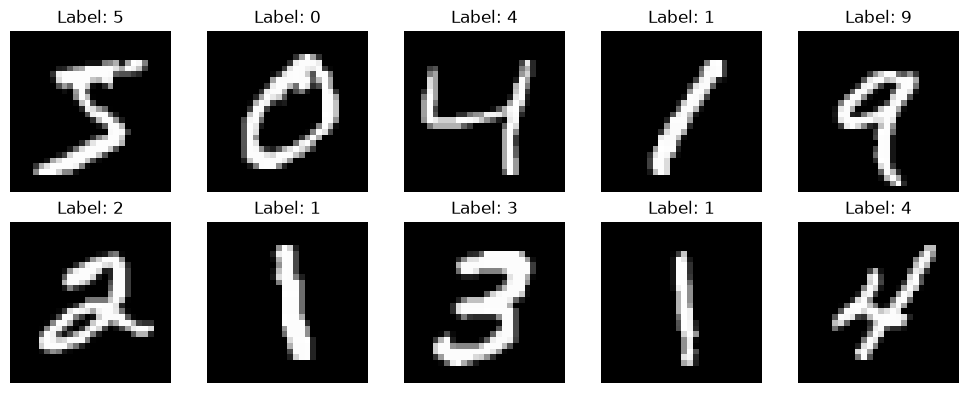

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.savefig("sample_digits.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Normalize pixel values from 0-255 down to 0-1
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# Flatten each 28x28 image into a single row of 784 numbers
X_train_flat = X_train_norm.reshape(-1, 28 * 28)
X_test_flat = X_test_norm.reshape(-1, 28 * 28)

print("Flattened training shape:", X_train_flat.shape)
print("Flattened testing shape:", X_test_flat.shape)
print("\nPixel value range - min:", X_train_flat.min(), "max:", X_train_flat.max())

Flattened training shape: (60000, 784)
Flattened testing shape: (10000, 784)

Pixel value range - min: 0.0 max: 1.0


In [5]:
from tensorflow.keras import layers, models

# Build the model layer by layer
model = models.Sequential([
    layers.Dense(128, activation="relu", input_shape=(784,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Show a summary of the architecture we just built
model.summary()

C:\tfenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile: configure how the model should learn
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the model
history = model.fit(
    X_train_flat, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9242 - loss: 0.2581 - val_accuracy: 0.9687 - val_loss: 0.1079
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9673 - loss: 0.1090 - val_accuracy: 0.9743 - val_loss: 0.0857
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9765 - loss: 0.0769 - val_accuracy: 0.9750 - val_loss: 0.0860
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9812 - loss: 0.0591 - val_accuracy: 0.9750 - val_loss: 0.0961
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9852 - loss: 0.0457 - val_accuracy: 0.9738 - val_loss: 0.1004
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9894 - loss: 0.0348 - val_accuracy: 0.9750 - val_loss: 0.1000
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9900 - loss: 0.0309 - val_accuracy: 0.9743 - val_loss: 0.1126
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9905 - loss: 0.0276 -

In [7]:
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test)
print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9777 - loss: 0.0890
Test accuracy: 0.9776999950408936
Test loss: 0.08904525637626648


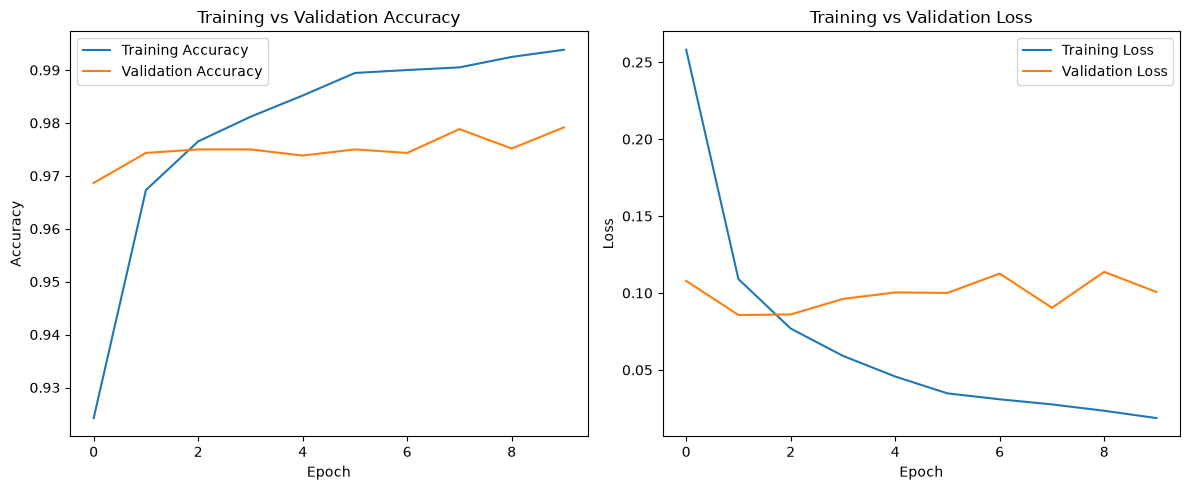

In [8]:
plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Build a fresh model (same architecture as before)
model_tuned = models.Sequential([
    layers.Dense(128, activation="relu", input_shape=(784,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_tuned.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train for only 3 epochs this time, based on what our curves showed us
history_tuned = model_tuned.fit(
    X_train_flat, y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

# Evaluate on the test set
test_loss_tuned, test_accuracy_tuned = model_tuned.evaluate(X_test_flat, y_test)
print("\nTuned model test accuracy:", test_accuracy_tuned)
print("Original model test accuracy:", test_accuracy)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9253 - loss: 0.2543 - val_accuracy: 0.9718 - val_loss: 0.1014
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9678 - loss: 0.1068 - val_accuracy: 0.9707 - val_loss: 0.0960
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9767 - loss: 0.0743 - val_accuracy: 0.9743 - val_loss: 0.0915
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9698 - loss: 0.0966

Tuned model test accuracy: 0.9697999954223633
Original model test accuracy: 0.9776999950408936
